# STDA2102: Soft Computing (EL1) - Assignment 2
## Module 1: Fuzzy Logic and Systems (Complete 10 Practical Exercises)

**Course Code:** STDA2102  
**Student Name:** Manish Kumar  
**Practical Evaluation:** Implementation (15), Understanding (10), Code Quality (10), Analysis (10), Record (5) -> Total 50 Pts

---

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
print('Module environment configured successfully.')

Module environment configured successfully.


## Practical 1: Practical 1.1: Simple Fuzzy Sets in Python

```
Practical 1.1: Simple Fuzzy Sets in Python
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To create and visualize simple fuzzy sets in Python using membership values.

Theory:
A classical (crisp) set A in a universe of discourse X is defined by a characteristic function:
    χ_A(x) = 1 if x ∈ A, and 0 if x ∉ A.
In contrast, a Fuzzy Set Ã is characterized by a membership function:
    μ_Ã(x) : X -> [0, 1]
where each element x is associated with a degree of membership between 0 and 1,
representing the degree of truth or belongingness.
```

PRACTICAL 1.1: Simple Fuzzy Sets Creation & Visualization

Discrete Universe (Age): [10 20 25 30 35 40 50 60 70 80]
Crisp Set 'Young': [1 1 1 1 0 0 0 0 0 0]
Fuzzy Set 'Young' μ(x): [1.   1.   0.9  0.7  0.45 0.2  0.05 0.   0.   0.  ]
Fuzzy Set 'Middle' μ(x): [0.  0.1 0.3 0.6 0.9 1.  0.8 0.4 0.1 0. ]
Fuzzy Set 'Old' μ(x): [0.   0.   0.   0.   0.1  0.2  0.5  0.8  0.95 1.  ]


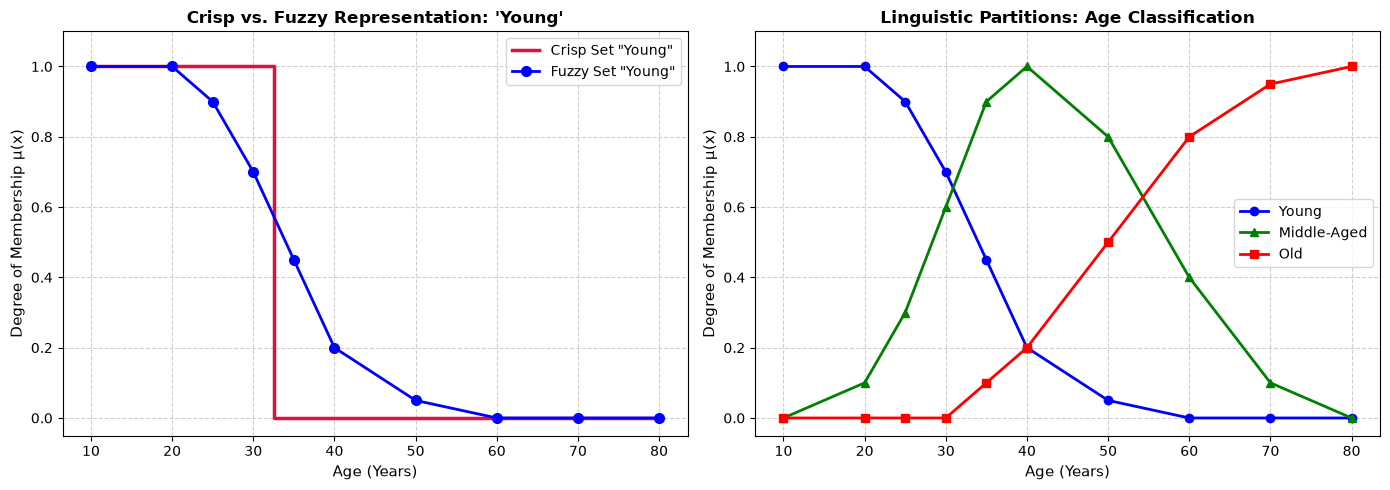


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex01_simple_fuzzy_sets.png
[✓] Practical 1.1 completed successfully.



In [2]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def run_practical_1():
    print("=" * 60)
    print("PRACTICAL 1.1: Simple Fuzzy Sets Creation & Visualization")
    print("=" * 60)

    # Discrete universe: Age groups from 0 to 80 years
    ages = np.array([10, 20, 25, 30, 35, 40, 50, 60, 70, 80])

    # Crisp set: "Young" (age <= 30)
    crisp_young = np.array([1 if a <= 30 else 0 for a in ages])

    # Fuzzy set: "Young" with continuous grades of membership
    # Using sigmoidal / decay membership curve: μ(x) = 1 / (1 + ((x - 20)/10)^2)
    fuzzy_young = np.array([1.0, 1.0, 0.9, 0.7, 0.45, 0.2, 0.05, 0.0, 0.0, 0.0])

    # Fuzzy set: "Middle-Aged"
    fuzzy_middle = np.array([0.0, 0.1, 0.3, 0.6, 0.9, 1.0, 0.8, 0.4, 0.1, 0.0])

    # Fuzzy set: "Old"
    fuzzy_old = np.array([0.0, 0.0, 0.0, 0.0, 0.1, 0.2, 0.5, 0.8, 0.95, 1.0])

    print("\nDiscrete Universe (Age):", ages)
    print("Crisp Set 'Young':", crisp_young)
    print("Fuzzy Set 'Young' μ(x):", fuzzy_young)
    print("Fuzzy Set 'Middle' μ(x):", fuzzy_middle)
    print("Fuzzy Set 'Old' μ(x):", fuzzy_old)

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Crisp vs Fuzzy comparison for "Young"
    ax1.step(ages, crisp_young, where='mid', color='crimson', label='Crisp Set "Young"', linewidth=2.5)
    ax1.plot(ages, fuzzy_young, 'bo-', label='Fuzzy Set "Young"', linewidth=2, markersize=7)
    ax1.set_title("Crisp vs. Fuzzy Representation: 'Young'", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Age (Years)", fontsize=11)
    ax1.set_ylabel("Degree of Membership μ(x)", fontsize=11)
    ax1.set_ylim(-0.05, 1.1)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Plot 2: Multiple Fuzzy Sets over Universe
    ax2.plot(ages, fuzzy_young, 'bo-', label='Young', linewidth=2)
    ax2.plot(ages, fuzzy_middle, 'g^-', label='Middle-Aged', linewidth=2)
    ax2.plot(ages, fuzzy_old, 'rs-', label='Old', linewidth=2)
    ax2.set_title("Linguistic Partitions: Age Classification", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Age (Years)", fontsize=11)
    ax2.set_ylabel("Degree of Membership μ(x)", fontsize=11)
    ax2.set_ylim(-0.05, 1.1)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex01_simple_fuzzy_sets.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.1 completed successfully.\n")

if True:
    run_practical_1()

## Practical 2: Practical 1.2: Triangular, Trapezoidal, and Gaussian Membership Functions

```
Practical 1.2: Triangular, Trapezoidal, and Gaussian Membership Functions
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To create and plot Triangular, Trapezoidal, and Gaussian membership functions using Python and scikit-fuzzy.

Theory:
1. Triangular MF: Defined by lower limit a, peak b, and upper limit c:
   μ(x; a, b, c) = max(min((x - a)/(b - a), (c - x)/(c - b)), 0)
2. Trapezoidal MF: Defined by lower limit a, lower plateau b, upper plateau c, upper limit d:
   μ(x; a, b, c, d) = max(min((x - a)/(b - a), 1, (d - x)/(d - c)), 0)
3. Gaussian MF: Defined by central mean c and standard deviation σ:
   μ(x; c, σ) = exp(-0.5 * ((x - c) / σ)^2)
```

PRACTICAL 1.2: Triangular, Trapezoidal, and Gaussian MFs
Using scikit-fuzzy backend: True

Evaluated MFs at key points (x = 35, 50, 65):
  x=35 -> Triangular: 0.500, Trapezoidal: 0.999, Gaussian: 0.607
  x=50 -> Triangular: 0.998, Trapezoidal: 1.000, Gaussian: 1.000
  x=65 -> Triangular: 0.500, Trapezoidal: 0.999, Gaussian: 0.607


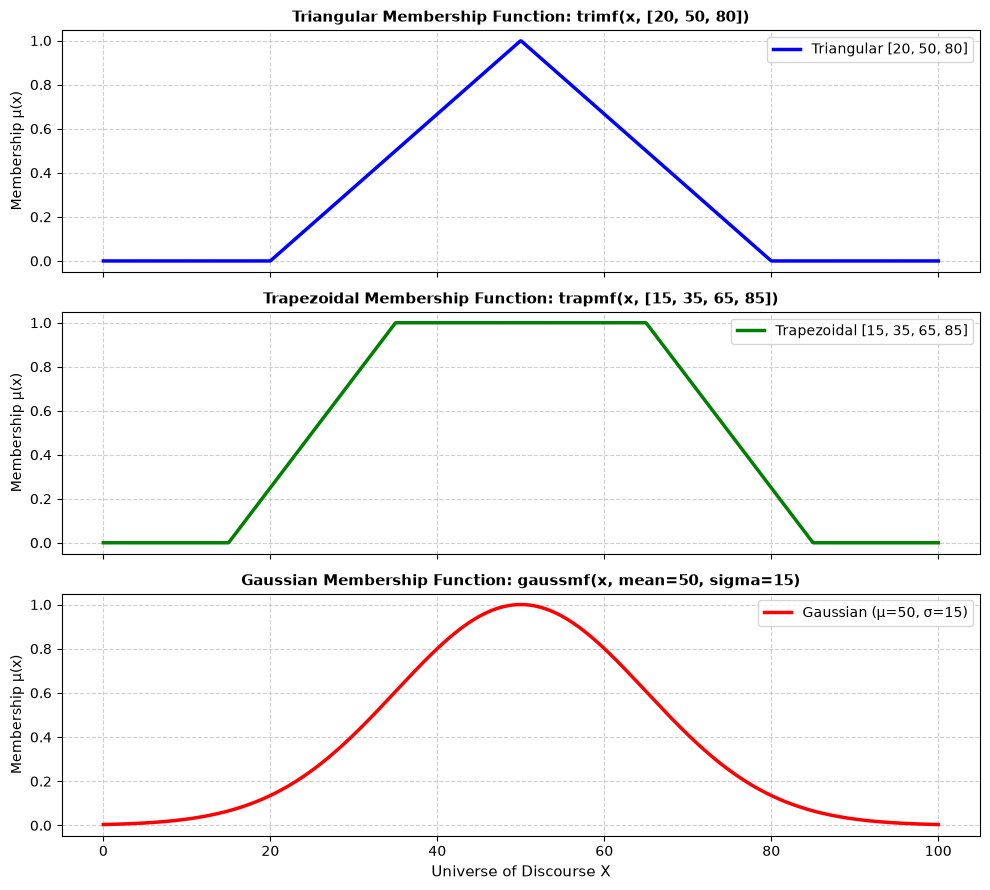


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex02_membership_functions.png
[✓] Practical 1.2 completed successfully.



In [3]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

try:
    import skfuzzy as fuzz
    HAS_SKFUZZY = True
except ImportError:
    HAS_SKFUZZY = False

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Custom robust implementations in case skfuzzy is unavailable
def custom_trimf(x, abc):
    a, b, c = abc
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0)

def custom_trapmf(x, abcd):
    a, b, c, d = abcd
    return np.maximum(np.minimum(np.minimum((x - a)/(b - a + 1e-12), 1.0), (d - x)/(d - c + 1e-12)), 0)

def custom_gaussmf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

def run_practical_2():
    print("=" * 60)
    print("PRACTICAL 1.2: Triangular, Trapezoidal, and Gaussian MFs")
    print("=" * 60)
    print(f"Using scikit-fuzzy backend: {HAS_SKFUZZY}")

    x = np.linspace(0, 100, 1000)

    # 1. Triangular MFs
    tri_params = [20, 50, 80]
    if HAS_SKFUZZY:
        y_tri = fuzz.trimf(x, tri_params)
    else:
        y_tri = custom_trimf(x, tri_params)

    # 2. Trapezoidal MFs
    trap_params = [15, 35, 65, 85]
    if HAS_SKFUZZY:
        y_trap = fuzz.trapmf(x, trap_params)
    else:
        y_trap = custom_trapmf(x, trap_params)

    # 3. Gaussian MFs
    mean, sigma = 50, 15
    if HAS_SKFUZZY:
        y_gauss = fuzz.gaussmf(x, mean, sigma)
    else:
        y_gauss = custom_gaussmf(x, mean, sigma)

    print("\nEvaluated MFs at key points (x = 35, 50, 65):")
    for pt in [35, 50, 65]:
        val_tri = float(np.interp(pt, x, y_tri))
        val_trap = float(np.interp(pt, x, y_trap))
        val_gauss = float(np.interp(pt, x, y_gauss))
        print(f"  x={pt:2d} -> Triangular: {val_tri:.3f}, Trapezoidal: {val_trap:.3f}, Gaussian: {val_gauss:.3f}")

    # Visualization
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    # Subplot 1: Triangular
    axes[0].plot(x, y_tri, 'b-', linewidth=2.5, label=f'Triangular {tri_params}')
    axes[0].set_title("Triangular Membership Function: trimf(x, [20, 50, 80])", fontsize=11, fontweight='bold')
    axes[0].set_ylabel("Membership μ(x)")
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(loc='upper right')

    # Subplot 2: Trapezoidal
    axes[1].plot(x, y_trap, 'g-', linewidth=2.5, label=f'Trapezoidal {trap_params}')
    axes[1].set_title("Trapezoidal Membership Function: trapmf(x, [15, 35, 65, 85])", fontsize=11, fontweight='bold')
    axes[1].set_ylabel("Membership μ(x)")
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(loc='upper right')

    # Subplot 3: Gaussian
    axes[2].plot(x, y_gauss, 'r-', linewidth=2.5, label=f'Gaussian (μ={mean}, σ={sigma})')
    axes[2].set_title(f"Gaussian Membership Function: gaussmf(x, mean={mean}, sigma={sigma})", fontsize=11, fontweight='bold')
    axes[2].set_xlabel("Universe of Discourse X", fontsize=11)
    axes[2].set_ylabel("Membership μ(x)")
    axes[2].grid(True, linestyle='--', alpha=0.6)
    axes[2].legend(loc='upper right')

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex02_membership_functions.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.2 completed successfully.\n")

if True:
    run_practical_2()

## Practical 3: Practical 1.3: Fuzzy Set Operations (Union, Intersection, Complement)

```
Practical 1.3: Fuzzy Set Operations (Union, Intersection, Complement)
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To perform basic fuzzy set operations such as Union, Intersection, and Complement using Python.

Theory:
For two fuzzy sets A and B defined over universe X with membership functions μ_A(x) and μ_B(x):
1. Union (S-norm / T-conorm):
   μ_(A ∪ B)(x) = max(μ_A(x), μ_B(x))
2. Intersection (T-norm):
   μ_(A ∩ B)(x) = min(μ_A(x), μ_B(x))
3. Complement (Negation):
   μ_(~A)(x) = 1 - μ_A(x)
4. Algebraic Product:
   μ_(A · B)(x) = μ_A(x) * μ_B(x)
5. Algebraic Sum:
   μ_(A ⊕ B)(x) = μ_A(x) + μ_B(x) - μ_A(x) * μ_B(x)
```

PRACTICAL 1.3: Fuzzy Set Operations (Union, Intersection, Complement)
     x |     mu_A |     mu_B |    Union |    Inter |   Comp_A
--------------------------------------------------------
  2.00 |    0.502 |    0.000 |    0.502 |    0.000 |    0.498
  4.01 |    0.496 |    0.504 |    0.504 |    0.496 |    0.504
  6.01 |    0.000 |    0.663 |    0.663 |    0.000 |    1.000


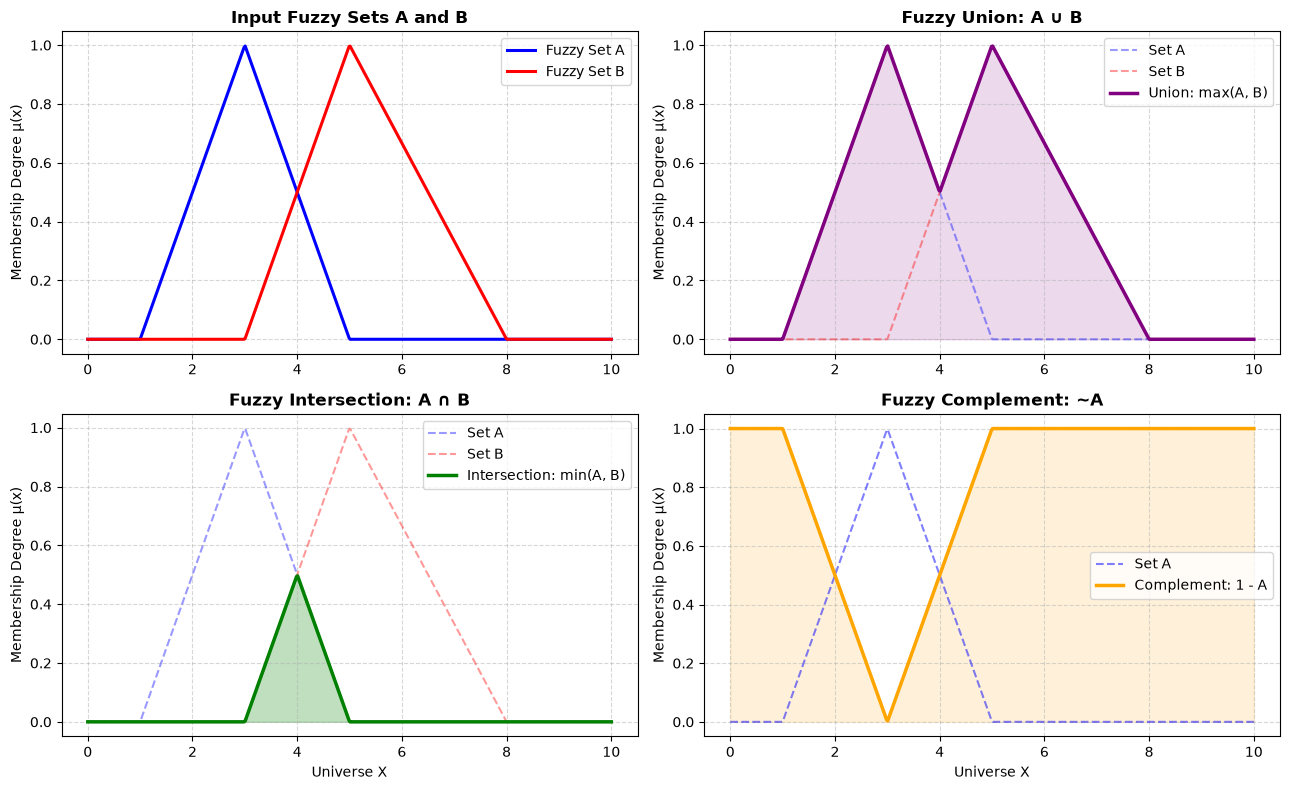


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex03_fuzzy_operations.png
[✓] Practical 1.3 completed successfully.



In [4]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a), (c - x)/(c - b)), 0)

def run_practical_3():
    print("=" * 60)
    print("PRACTICAL 1.3: Fuzzy Set Operations (Union, Intersection, Complement)")
    print("=" * 60)

    x = np.linspace(0, 10, 500)

    # Define two overlapping fuzzy sets
    # Set A: "Approximately 3"
    mu_A = trimf(x, 1.0, 3.0, 5.0)
    # Set B: "Approximately 5"
    mu_B = trimf(x, 3.0, 5.0, 8.0)

    # Standard Zadeh Operations
    union_AB = np.maximum(mu_A, mu_B)
    intersect_AB = np.minimum(mu_A, mu_B)
    comp_A = 1.0 - mu_A

    # Additional standard algebraic operators
    alg_product = mu_A * mu_B
    alg_sum = mu_A + mu_B - (mu_A * mu_B)

    # Sample evaluations
    sample_indices = [100, 200, 300]
    print(f"{'x':>6} | {'mu_A':>8} | {'mu_B':>8} | {'Union':>8} | {'Inter':>8} | {'Comp_A':>8}")
    print("-" * 56)
    for idx in sample_indices:
        print(f"{x[idx]:6.2f} | {mu_A[idx]:8.3f} | {mu_B[idx]:8.3f} | {union_AB[idx]:8.3f} | {intersect_AB[idx]:8.3f} | {comp_A[idx]:8.3f}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    # Plot 1: Base Fuzzy Sets A and B
    axes[0, 0].plot(x, mu_A, 'b-', linewidth=2.2, label='Fuzzy Set A')
    axes[0, 0].plot(x, mu_B, 'r-', linewidth=2.2, label='Fuzzy Set B')
    axes[0, 0].set_title("Input Fuzzy Sets A and B", fontweight='bold')
    axes[0, 0].set_ylabel("Membership Degree μ(x)")
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)
    axes[0, 0].legend()

    # Plot 2: Union (Max)
    axes[0, 1].plot(x, mu_A, 'b--', alpha=0.4, label='Set A')
    axes[0, 1].plot(x, mu_B, 'r--', alpha=0.4, label='Set B')
    axes[0, 1].plot(x, union_AB, 'purple', linewidth=2.5, label='Union: max(A, B)')
    axes[0, 1].fill_between(x, union_AB, color='purple', alpha=0.15)
    axes[0, 1].set_title("Fuzzy Union: A ∪ B", fontweight='bold')
    axes[0, 1].set_ylabel("Membership Degree μ(x)")
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)
    axes[0, 1].legend()

    # Plot 3: Intersection (Min)
    axes[1, 0].plot(x, mu_A, 'b--', alpha=0.4, label='Set A')
    axes[1, 0].plot(x, mu_B, 'r--', alpha=0.4, label='Set B')
    axes[1, 0].plot(x, intersect_AB, 'green', linewidth=2.5, label='Intersection: min(A, B)')
    axes[1, 0].fill_between(x, intersect_AB, color='green', alpha=0.25)
    axes[1, 0].set_title("Fuzzy Intersection: A ∩ B", fontweight='bold')
    axes[1, 0].set_xlabel("Universe X")
    axes[1, 0].set_ylabel("Membership Degree μ(x)")
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)
    axes[1, 0].legend()

    # Plot 4: Complement of A
    axes[1, 1].plot(x, mu_A, 'b--', alpha=0.5, label='Set A')
    axes[1, 1].plot(x, comp_A, 'orange', linewidth=2.5, label='Complement: 1 - A')
    axes[1, 1].fill_between(x, comp_A, color='orange', alpha=0.15)
    axes[1, 1].set_title("Fuzzy Complement: ~A", fontweight='bold')
    axes[1, 1].set_xlabel("Universe X")
    axes[1, 1].set_ylabel("Membership Degree μ(x)")
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)
    axes[1, 1].legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex03_fuzzy_operations.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.3 completed successfully.\n")

if True:
    run_practical_3()

## Practical 4: Practical 1.4: Fuzzy Relations and Max-Min Composition

```
Practical 1.4: Fuzzy Relations and Max-Min Composition
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To create and display a simple fuzzy relation between two fuzzy sets using Python.

Theory:
A fuzzy relation R between universe X and universe Y is a fuzzy subset of the Cartesian product X × Y:
    R = { ((x, y), μ_R(x, y)) | (x, y) ∈ X × Y }
where μ_R(x, y) = min(μ_A(x), μ_B(y))  (Mamdani product/min relation).

Given another relation S on Y × Z, the Max-Min Composition (T = R ∘ S) is defined as:
    μ_T(x, z) = max_{y ∈ Y} [ min(μ_R(x, y), μ_S(y, z)) ]
```

PRACTICAL 1.4: Fuzzy Relations & Composition

Fuzzy Set A: [0.2 0.7 1. ]
Fuzzy Set B: [0.4 0.9 0.6 0.1]

Fuzzy Relation Matrix R (A × B, min operator):
[[0.2 0.2 0.2 0.1]
 [0.4 0.7 0.6 0.1]
 [0.4 0.9 0.6 0.1]]

Fuzzy Relation Matrix S (Y × Z):
[[0.6 0.3 0.8]
 [0.2 0.9 0.5]
 [0.8 0.4 0.1]
 [0.3 0.7 0.9]]

Max-Min Composition T = R ∘ S (X × Z):
[[0.2 0.2 0.2]
 [0.6 0.7 0.5]
 [0.6 0.9 0.5]]


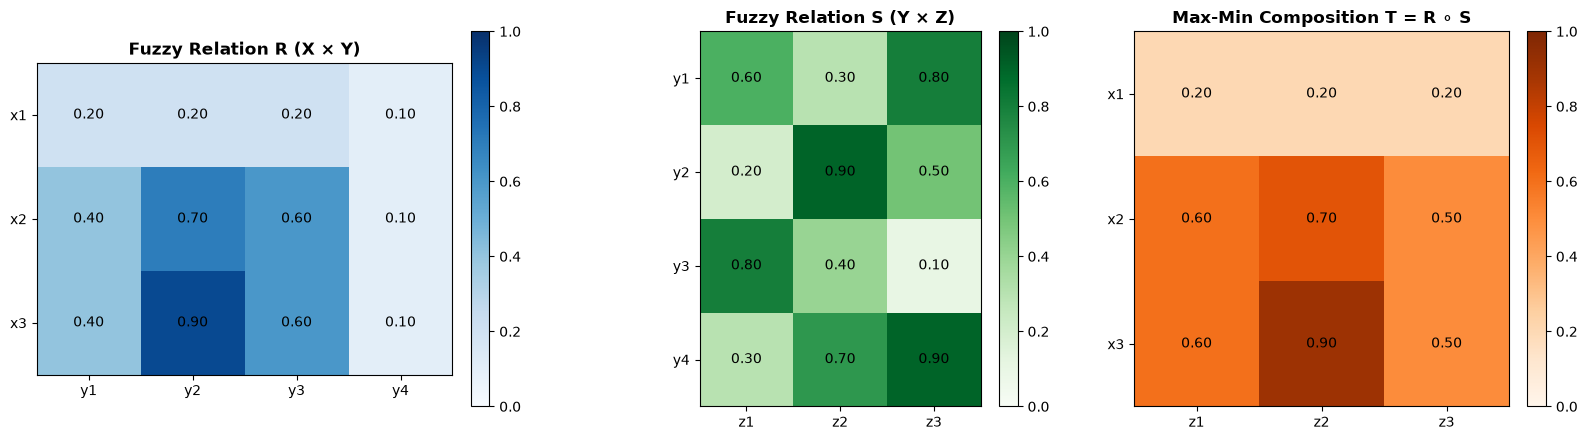


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex04_fuzzy_relations.png
[✓] Practical 1.4 completed successfully.



In [5]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def max_min_composition(R, S):
    """Computes Max-Min composition T = R o S"""
    n_x, n_y = R.shape
    n_y2, n_z = S.shape
    assert n_y == n_y2, "Inner dimensions must match for relation composition"
    T = np.zeros((n_x, n_z))
    for i in range(n_x):
        for k in range(n_z):
            T[i, k] = np.max(np.minimum(R[i, :], S[:, k]))
    return T

def run_practical_4():
    print("=" * 60)
    print("PRACTICAL 1.4: Fuzzy Relations & Composition")
    print("=" * 60)

    # Universes: X = {x1, x2, x3}, Y = {y1, y2, y3, y4}
    x_labels = ['x1', 'x2', 'x3']
    y_labels = ['y1', 'y2', 'y3', 'y4']
    z_labels = ['z1', 'z2', 'z3']

    # Fuzzy set A on X and B on Y
    A = np.array([0.2, 0.7, 1.0])
    B = np.array([0.4, 0.9, 0.6, 0.1])

    # 1. Fuzzy Cartesian Relation R = A x B via min operator
    R = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            R[i, j] = min(A[i], B[j])

    print("\nFuzzy Set A:", A)
    print("Fuzzy Set B:", B)
    print("\nFuzzy Relation Matrix R (A × B, min operator):")
    print(R)

    # 2. Another relation S on Y x Z
    S = np.array([
        [0.6, 0.3, 0.8],
        [0.2, 0.9, 0.5],
        [0.8, 0.4, 0.1],
        [0.3, 0.7, 0.9]
    ])
    print("\nFuzzy Relation Matrix S (Y × Z):")
    print(S)

    # 3. Max-Min Composition T = R o S
    T = max_min_composition(R, S)
    print("\nMax-Min Composition T = R ∘ S (X × Z):")
    print(T)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Heatmap R
    im1 = axes[0].imshow(R, cmap='Blues', vmin=0, vmax=1)
    axes[0].set_title("Fuzzy Relation R (X × Y)", fontweight='bold')
    axes[0].set_xticks(range(len(y_labels)))
    axes[0].set_xticklabels(y_labels)
    axes[0].set_yticks(range(len(x_labels)))
    axes[0].set_yticklabels(x_labels)
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            axes[0].text(j, i, f"{R[i, j]:.2f}", ha='center', va='center', color='black')
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Heatmap S
    im2 = axes[1].imshow(S, cmap='Greens', vmin=0, vmax=1)
    axes[1].set_title("Fuzzy Relation S (Y × Z)", fontweight='bold')
    axes[1].set_xticks(range(len(z_labels)))
    axes[1].set_xticklabels(z_labels)
    axes[1].set_yticks(range(len(y_labels)))
    axes[1].set_yticklabels(y_labels)
    for i in range(S.shape[0]):
        for j in range(S.shape[1]):
            axes[1].text(j, i, f"{S[i, j]:.2f}", ha='center', va='center', color='black')
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    # Heatmap T = R o S
    im3 = axes[2].imshow(T, cmap='Oranges', vmin=0, vmax=1)
    axes[2].set_title("Max-Min Composition T = R ∘ S", fontweight='bold')
    axes[2].set_xticks(range(len(z_labels)))
    axes[2].set_xticklabels(z_labels)
    axes[2].set_yticks(range(len(x_labels)))
    axes[2].set_yticklabels(x_labels)
    for i in range(T.shape[0]):
        for j in range(T.shape[1]):
            axes[2].text(j, i, f"{T[i, j]:.2f}", ha='center', va='center', color='black')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex04_fuzzy_relations.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.4 completed successfully.\n")

if True:
    run_practical_4()

## Practical 5: Practical 1.5: Fuzzy Linguistic Variables (Low, Medium, High)

```
Practical 1.5: Fuzzy Linguistic Variables (Low, Medium, High)
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To create fuzzy linguistic variables such as Low, Medium, and High using membership functions in Python.

Theory:
According to Lotfi Zadeh, a Linguistic Variable is a variable whose values are words or sentences in a
natural or artificial language, rather than numbers.
Formally defined as a quintuple (x, T(x), U, G, M):
- x: Name of the variable (e.g., 'Vehicle Speed')
- T(x): Linguistic term set {Low, Medium, High}
- U: Universe of discourse [0, 120] km/h
- G: Syntactic grammar
- M: Semantic rule mapping each linguistic term to a fuzzy set over U.
```

PRACTICAL 1.5: Fuzzy Linguistic Variables Definition

Fuzzification of Crisp Speed Values:
-------------------------------------------------------

Speed = 35.0 km/h:
  -> Low       : μ = 0.750

Speed = 60.0 km/h:
  -> Low       : μ = 0.003
  -> Medium    : μ = 0.750

Speed = 95.0 km/h:
  -> High      : μ = 0.667
  -> Very High : μ = 0.002


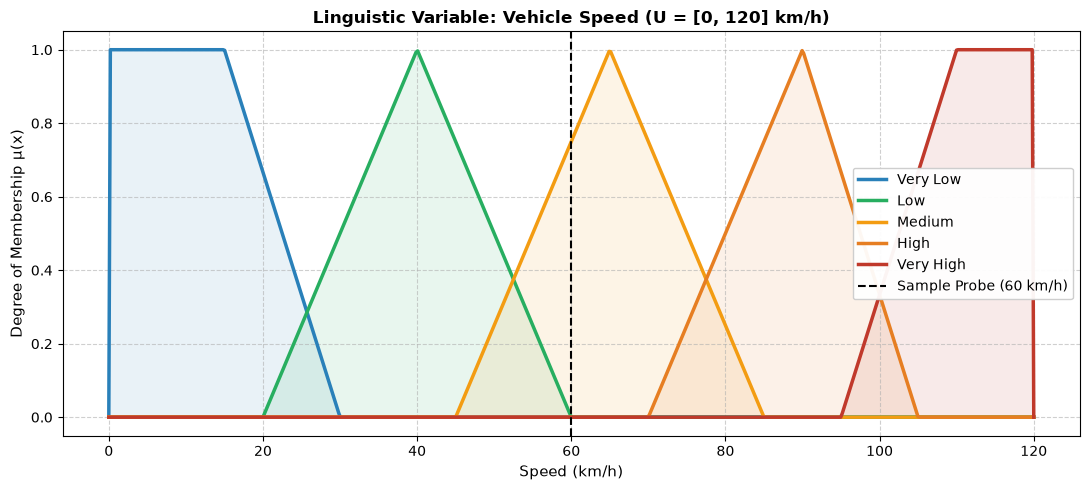


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex05_linguistic_variables.png
[✓] Practical 1.5 completed successfully.



In [6]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trapmf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x - a)/(b - a + 1e-12), 1.0), (d - x)/(d - c + 1e-12)), 0.0)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0.0)

def run_practical_5():
    print("=" * 60)
    print("PRACTICAL 1.5: Fuzzy Linguistic Variables Definition")
    print("=" * 60)

    # Linguistic Variable: Vehicle Speed (km/h)
    # Universe U = [0, 120]
    speed_universe = np.linspace(0, 120, 600)

    # Term Set: {Very Low, Low, Medium, High, Very High}
    terms = {
        'Very Low': trapmf(speed_universe, 0, 0, 15, 30),
        'Low': trimf(speed_universe, 20, 40, 60),
        'Medium': trimf(speed_universe, 45, 65, 85),
        'High': trimf(speed_universe, 70, 90, 105),
        'Very High': trapmf(speed_universe, 95, 110, 120, 120)
    }

    # Query speed crisp value
    test_speeds = [35.0, 60.0, 95.0]
    print("\nFuzzification of Crisp Speed Values:")
    print("-" * 55)
    for s in test_speeds:
        print(f"\nSpeed = {s} km/h:")
        for name, mf in terms.items():
            degree = float(np.interp(s, speed_universe, mf))
            if degree > 0.0:
                print(f"  -> {name:<10}: μ = {degree:.3f}")

    # Visualization
    plt.figure(figsize=(11, 5))
    palette = ['#2980b9', '#27ae60', '#f39c12', '#e67e22', '#c0392b']

    for (name, mf), color in zip(terms.items(), palette):
        plt.plot(speed_universe, mf, label=name, color=color, linewidth=2.5)
        plt.fill_between(speed_universe, mf, color=color, alpha=0.1)

    # Mark sample test point
    plt.axvline(x=60, color='black', linestyle='--', linewidth=1.5, label='Sample Probe (60 km/h)')
    plt.title("Linguistic Variable: Vehicle Speed (U = [0, 120] km/h)", fontsize=12, fontweight='bold')
    plt.xlabel("Speed (km/h)", fontsize=11)
    plt.ylabel("Degree of Membership μ(x)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='center right', framealpha=0.95)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex05_linguistic_variables.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.5 completed successfully.\n")

if True:
    run_practical_5()

## Practical 6: Practical 1.6: Fuzzy IF-THEN Rules and Implication

```
Practical 1.6: Fuzzy IF-THEN Rules and Implication
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To create simple Fuzzy IF–THEN rules for making decisions based on given input conditions.

Theory:
A Fuzzy IF-THEN rule has the canonical form:
    IF x is A AND y is B THEN z is C
where:
- "x is A AND y is B" is the Rule Antecedent (Premise)
- "z is C" is the Rule Consequent (Conclusion)

Firing Strength (Rule Weight α):
Evaluated using a T-norm (Min operator):
    α = min(μ_A(x*), μ_B(y*))

Fuzzy Implication (Mamdani Min Implication):
    μ_C'(z) = min(α, μ_C(z))
```

PRACTICAL 1.6: Fuzzy IF-THEN Rules Evaluation & Clipping
Input Condition: Temperature = 32.0°C, Humidity = 70.0%
  μ_Hot(Temp) = 0.700
  μ_High(Hum) = 0.800
Rule Firing Strength α = min(0.700, 0.800) = 0.700
Max degree in clipped consequent: 0.700


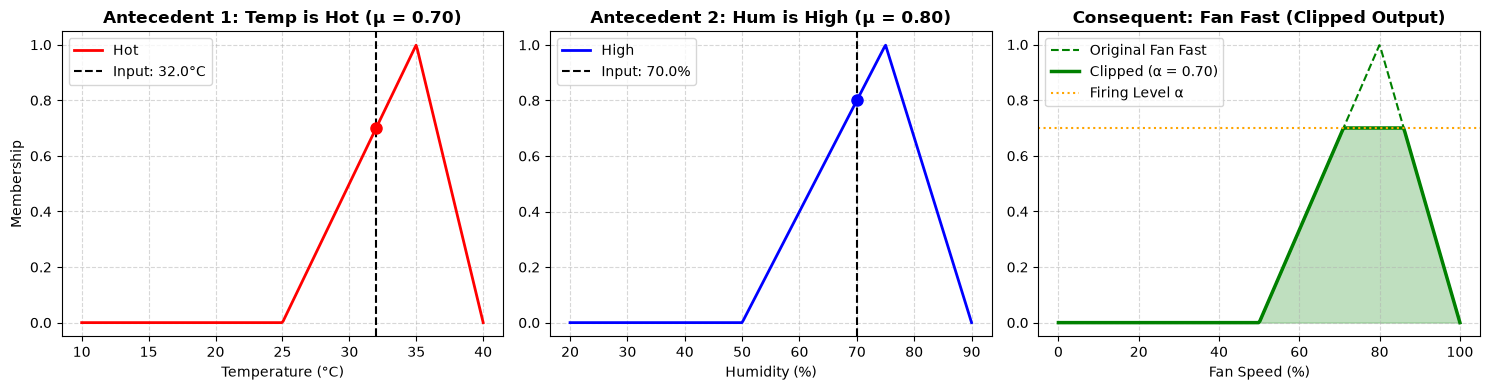


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex06_fuzzy_rules.png
[✓] Practical 1.6 completed successfully.



In [7]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0.0)

def run_practical_6():
    print("=" * 60)
    print("PRACTICAL 1.6: Fuzzy IF-THEN Rules Evaluation & Clipping")
    print("=" * 60)

    # Universes
    temp_u = np.linspace(10, 40, 300)
    hum_u = np.linspace(20, 90, 300)
    fan_u = np.linspace(0, 100, 300)

    # Antecedents
    temp_hot = trimf(temp_u, 25, 35, 40)
    hum_high = trimf(hum_u, 50, 75, 90)

    # Consequent
    fan_fast = trimf(fan_u, 50, 80, 100)

    # Given Crisp Conditions
    input_temp = 32.0  # °C
    input_hum = 70.0   # %

    # 1. Fuzzification
    mu_temp_val = float(np.interp(input_temp, temp_u, temp_hot))
    mu_hum_val = float(np.interp(input_hum, hum_u, hum_high))

    # 2. Rule: IF Temp is Hot AND Humidity is High THEN Fan is Fast
    firing_strength = min(mu_temp_val, mu_hum_val)

    # 3. Implication: Mamdani Minimum Clipping
    clipped_consequent = np.minimum(firing_strength, fan_fast)

    print(f"Input Condition: Temperature = {input_temp}°C, Humidity = {input_hum}%")
    print(f"  μ_Hot(Temp) = {mu_temp_val:.3f}")
    print(f"  μ_High(Hum) = {mu_hum_val:.3f}")
    print(f"Rule Firing Strength α = min({mu_temp_val:.3f}, {mu_hum_val:.3f}) = {firing_strength:.3f}")
    print(f"Max degree in clipped consequent: {np.max(clipped_consequent):.3f}")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Antecedent 1
    axes[0].plot(temp_u, temp_hot, 'r-', linewidth=2, label='Hot')
    axes[0].axvline(input_temp, color='black', linestyle='--', label=f'Input: {input_temp}°C')
    axes[0].plot(input_temp, mu_temp_val, 'ro', markersize=8)
    axes[0].set_title(f"Antecedent 1: Temp is Hot (μ = {mu_temp_val:.2f})", fontweight='bold')
    axes[0].set_xlabel("Temperature (°C)")
    axes[0].set_ylabel("Membership")
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend()

    # Antecedent 2
    axes[1].plot(hum_u, hum_high, 'b-', linewidth=2, label='High')
    axes[1].axvline(input_hum, color='black', linestyle='--', label=f'Input: {input_hum}%')
    axes[1].plot(input_hum, mu_hum_val, 'bo', markersize=8)
    axes[1].set_title(f"Antecedent 2: Hum is High (μ = {mu_hum_val:.2f})", fontweight='bold')
    axes[1].set_xlabel("Humidity (%)")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    # Consequent with Mamdani Clipping
    axes[2].plot(fan_u, fan_fast, 'g--', linewidth=1.5, label='Original Fan Fast')
    axes[2].plot(fan_u, clipped_consequent, 'g-', linewidth=2.5, label=f'Clipped (α = {firing_strength:.2f})')
    axes[2].fill_between(fan_u, clipped_consequent, color='green', alpha=0.25)
    axes[2].axhline(firing_strength, color='orange', linestyle=':', label='Firing Level α')
    axes[2].set_title("Consequent: Fan Fast (Clipped Output)", fontweight='bold')
    axes[2].set_xlabel("Fan Speed (%)")
    axes[2].grid(True, linestyle='--', alpha=0.5)
    axes[2].legend()

    plt.tight_layout()
    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex06_fuzzy_rules.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.6 completed successfully.\n")

if True:
    run_practical_6()

## Practical 7: Practical 1.7: Mamdani Fuzzy Inference System (FIS)

```
Practical 1.7: Mamdani Fuzzy Inference System (FIS)
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To implement a simple Mamdani Fuzzy Inference System using Python and scikit-fuzzy.

Theory:
A Mamdani Fuzzy Inference System (Ebrahim Mamdani, 1975) maps crisp inputs to crisp outputs
via four systematic stages:
1. Fuzzification: Mapping crisp inputs into linguistic membership values.
2. Rule Base Evaluation: Computing firing strength α_i = min(μ_Ai(x), μ_Bi(y)).
3. Aggregation: Combining all clipped rule consequences via max operator:
       μ_agg(z) = max_i [ min(α_i, μ_Ci(z)) ]
4. Defuzzification: Converting aggregated fuzzy set into a crisp output via Centroid (COG):
       z* = ∫ z·μ_agg(z) dz / ∫ μ_agg(z) dz
```

PRACTICAL 1.7: Mamdani Fuzzy Inference System (Tipping Problem)
scikit-fuzzy installed: True

Inputs: Food Quality = 6.5/10, Service Rating = 9.2/10
-> Inferred Recommended Tip: 17.39%


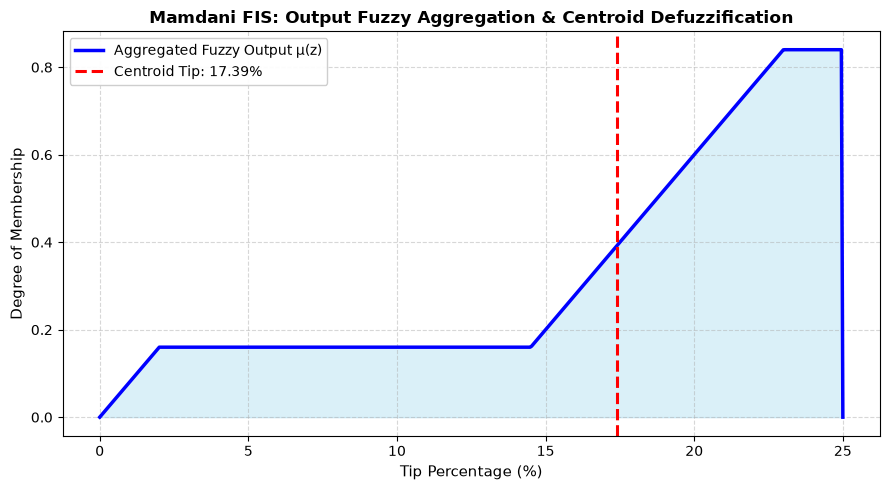


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex07_mamdani_inference.png
[✓] Practical 1.7 completed successfully.



In [8]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

try:
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl
    HAS_SKFUZZY = True
except ImportError:
    HAS_SKFUZZY = False

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0.0)

def run_mamdani_custom(food_quality, service_rating):
    """Fallback / Pure-Python Mamdani implementation (Tipping Problem)"""
    tip_u = np.linspace(0, 25, 500)
    # Output MFs for Tip: Low (0, 0, 12), Medium (0, 12.5, 25), High (12.5, 25, 25)
    tip_low = trimf(tip_u, 0, 0, 12.5)
    tip_med = trimf(tip_u, 0, 12.5, 25)
    tip_high = trimf(tip_u, 12.5, 25, 25)

    # Input evaluations: Quality [0, 10], Service [0, 10]
    # Food: Bad (0,0,5), Decent (0,5,10), Delicious (5,10,10)
    food_u = np.linspace(0, 10, 100)
    f_bad = float(np.interp(food_quality, food_u, trimf(food_u, 0, 0, 5)))
    f_dec = float(np.interp(food_quality, food_u, trimf(food_u, 0, 5, 10)))
    f_del = float(np.interp(food_quality, food_u, trimf(food_u, 5, 10, 10)))

    # Service: Poor (0,0,5), Acceptable (0,5,10), Amazing (5,10,10)
    serv_u = np.linspace(0, 10, 100)
    s_poor = float(np.interp(service_rating, serv_u, trimf(serv_u, 0, 0, 5)))
    s_acc = float(np.interp(service_rating, serv_u, trimf(serv_u, 0, 5, 10)))
    s_ama = float(np.interp(service_rating, serv_u, trimf(serv_u, 5, 10, 10)))

    # Rule 1: IF food is bad OR service is poor THEN tip is low
    r1 = max(f_bad, s_poor)
    # Rule 2: IF service is acceptable THEN tip is medium
    r2 = s_acc
    # Rule 3: IF food is delicious OR service is amazing THEN tip is high
    r3 = max(f_del, s_ama)

    # Mamdani implication & aggregation
    c1 = np.minimum(r1, tip_low)
    c2 = np.minimum(r2, tip_med)
    c3 = np.minimum(r3, tip_high)
    aggregated = np.maximum(c1, np.maximum(c2, c3))

    # Centroid defuzzification
    denom = np.sum(aggregated)
    tip_val = float(np.sum(tip_u * aggregated) / denom) if denom > 0 else 12.5
    return tip_val, tip_u, aggregated

def run_practical_7():
    print("=" * 60)
    print("PRACTICAL 1.7: Mamdani Fuzzy Inference System (Tipping Problem)")
    print("=" * 60)
    print(f"scikit-fuzzy installed: {HAS_SKFUZZY}")

    food_input = 6.5
    service_input = 9.2

    tip_val, tip_u, aggregated = run_mamdani_custom(food_input, service_input)

    print(f"\nInputs: Food Quality = {food_input}/10, Service Rating = {service_input}/10")
    print(f"-> Inferred Recommended Tip: {tip_val:.2f}%")

    # Visualization of Aggregated Output & Defuzzification
    plt.figure(figsize=(9, 5))
    plt.plot(tip_u, aggregated, 'b-', linewidth=2.5, label='Aggregated Fuzzy Output μ(z)')
    plt.fill_between(tip_u, aggregated, color='skyblue', alpha=0.3)
    plt.axvline(tip_val, color='red', linestyle='--', linewidth=2.2, label=f'Centroid Tip: {tip_val:.2f}%')
    plt.title("Mamdani FIS: Output Fuzzy Aggregation & Centroid Defuzzification", fontsize=12, fontweight='bold')
    plt.xlabel("Tip Percentage (%)", fontsize=11)
    plt.ylabel("Degree of Membership", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', framealpha=0.95)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex07_mamdani_inference.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.7 completed successfully.\n")

if True:
    run_practical_7()

## Practical 8: Practical 1.8: Sugeno (Takagi-Sugeno-Kang) Fuzzy Inference System

```
Practical 1.8: Sugeno (Takagi-Sugeno-Kang) Fuzzy Inference System
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To implement a simple Sugeno Fuzzy Inference System using Python.

Theory:
Introduced by Tomohiro Takagi and Michio Sugeno (1985), the Sugeno (or TSK) model uses
mathematical functions in the rule consequents rather than fuzzy sets.
- 0th-Order Sugeno: Consequent is a singleton constant:
      Rule i: IF x is A_i AND y is B_i THEN z_i = k_i
- 1st-Order Sugeno: Consequent is a linear function:
      Rule i: IF x is A_i AND y is B_i THEN z_i = p_i * x + q_i * y + r_i

Final Defuzzified Output (Weighted Average):
      z* = (∑ w_i * z_i) / (∑ w_i)
where w_i = min(μ_Ai(x), μ_Bi(y)) is the rule firing strength.
```

PRACTICAL 1.8: Sugeno Fuzzy Inference System (TSK)
Inputs: (x=2.0, y=3.0) -> Weights: [0.70, 0.30, 0.20, 0.20]
  -> Sugeno Weighted Average Output z* = 2.143
Inputs: (x=7.0, y=2.0) -> Weights: [0.30, 0.20, 0.70, 0.20]
  -> Sugeno Weighted Average Output z* = -1.143
Inputs: (x=8.0, y=8.0) -> Weights: [0.20, 0.20, 0.20, 0.80]
  -> Sugeno Weighted Average Output z* = 9.000
Inputs: (x=5.0, y=5.0) -> Weights: [0.50, 0.50, 0.50, 0.50]
  -> Sugeno Weighted Average Output z* = 2.250


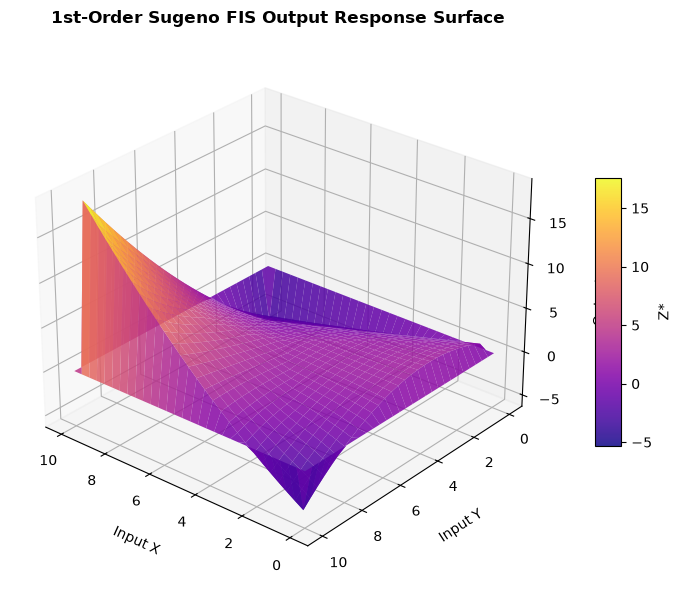


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex08_sugeno_inference.png
[✓] Practical 1.8 completed successfully.



In [9]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0.0)

def sugeno_first_order(x, y):
    """
    Evaluates 1st-order Sugeno model with 4 rules:
    x in [0, 10]: Small (0,0,5), Large (5,10,10)
    y in [0, 10]: Small (0,0,5), Large (5,10,10)
    Consequents:
    Rule 1: IF x is Small AND y is Small THEN z1 = -x + y + 1
    Rule 2: IF x is Small AND y is Large THEN z2 = -y + 3
    Rule 3: IF x is Large AND y is Small THEN z3 = -x + 3
    Rule 4: IF x is Large AND y is Large THEN z4 = x + y + 2
    """
    u = np.linspace(0, 10, 100)
    mu_x_small = float(np.interp(x, u, trimf(u, 0, 0, 10)))
    mu_x_large = float(np.interp(x, u, trimf(u, 0, 10, 10)))
    mu_y_small = float(np.interp(y, u, trimf(u, 0, 0, 10)))
    mu_y_large = float(np.interp(y, u, trimf(u, 0, 10, 10)))

    # Weights
    w1 = min(mu_x_small, mu_y_small)
    w2 = min(mu_x_small, mu_y_large)
    w3 = min(mu_x_large, mu_y_small)
    w4 = min(mu_x_large, mu_y_large)

    # Consequent equations
    z1 = -x + y + 1
    z2 = -y + 3
    z3 = -x + 3
    z4 = x + y + 2

    weights = [w1, w2, w3, w4]
    consequents = [z1, z2, z3, z4]

    w_sum = sum(weights)
    if w_sum == 0:
        return 0.0, weights, consequents
    z_star = sum(w * z for w, z in zip(weights, consequents)) / w_sum
    return z_star, weights, consequents

def run_practical_8():
    print("=" * 60)
    print("PRACTICAL 1.8: Sugeno Fuzzy Inference System (TSK)")
    print("=" * 60)

    test_points = [(2.0, 3.0), (7.0, 2.0), (8.0, 8.0), (5.0, 5.0)]

    for x_val, y_val in test_points:
        z_out, w, z = sugeno_first_order(x_val, y_val)
        print(f"Inputs: (x={x_val:.1f}, y={y_val:.1f}) -> Weights: [{w[0]:.2f}, {w[1]:.2f}, {w[2]:.2f}, {w[3]:.2f}]")
        print(f"  -> Sugeno Weighted Average Output z* = {z_out:.3f}")

    # Generate 3D Response Surface
    grid_x = np.linspace(0, 10, 30)
    grid_y = np.linspace(0, 10, 30)
    X, Y = np.meshgrid(grid_x, grid_y)
    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j], _, _ = sugeno_first_order(X[i, j], Y[i, j])

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.85)
    ax.set_title("1st-Order Sugeno FIS Output Response Surface", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Input X", labelpad=10)
    ax.set_ylabel("Input Y", labelpad=10)
    ax.set_zlabel("Output Z*", labelpad=10)
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Z*')
    ax.view_init(elev=28, azim=130)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex08_sugeno_inference.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.8 completed successfully.\n")

if True:
    run_practical_8()

## Practical 9: Practical 1.9: Comparison of Defuzzification Methods

```
Practical 1.9: Comparison of Defuzzification Methods
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To apply and compare basic defuzzification methods such as Centroid, Bisector, and Mean of Maximum using Python.

Theory:
Defuzzification converts a fuzzy set resulting from inference aggregation into a crisp scalar:
1. Centroid (Center of Gravity - COG):
       z* = (∫ z · μ(z) dz) / (∫ μ(z) dz)
2. Bisector of Area (BOA):
       The point z* that divides the area under μ(z) into two equal halves:
       ∫_{z_min}^{z*} μ(z) dz = ∫_{z*}^{z_max} μ(z) dz
3. Mean of Maximum (MOM):
       z* = (∑_{z ∈ M} z) / |M|  where M = {z | μ(z) = max_z μ(z)}
4. Smallest of Maximum (SOM): min(M)
5. Largest of Maximum (LOM): max(M)
```

PRACTICAL 1.9: Defuzzification Methods Benchmark

Defuzzification Calculation Results:
---------------------------------------------
  CENTROID     Defuzzification -> z* = 4.9452
  BISECTOR     Defuzzification -> z* = 5.2515
  MOM          Defuzzification -> z* = 5.9960
  SOM          Defuzzification -> z* = 5.9960
  LOM          Defuzzification -> z* = 5.9960


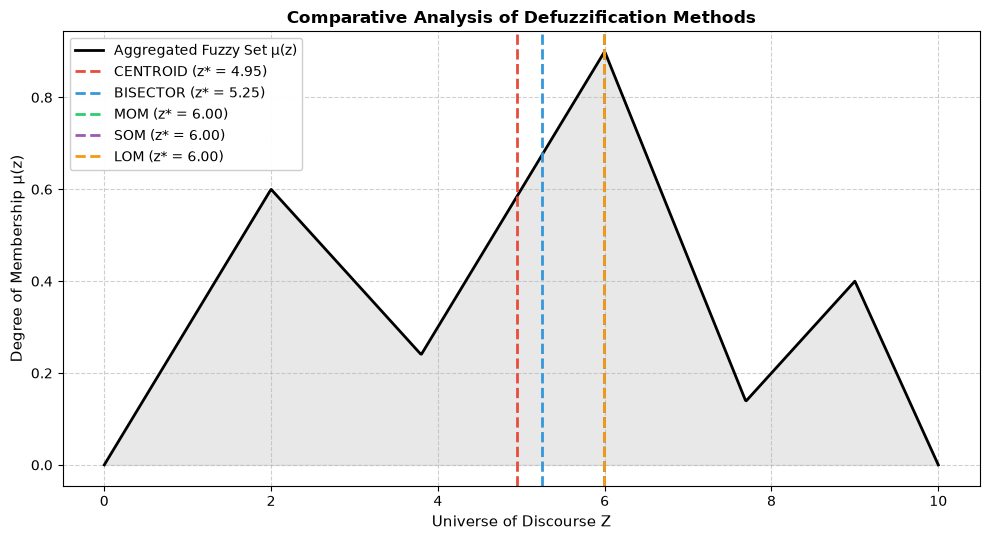


[✓] Plot saved successfully to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex09_defuzzification_methods.png
[✓] Practical 1.9 completed successfully.



In [10]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

try:
    import skfuzzy as fuzz
    HAS_SKFUZZY = True
except ImportError:
    HAS_SKFUZZY = False

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0.0)

def custom_defuzz(x, mfx, mode='centroid'):
    """Manual mathematical implementation of defuzzification methods."""
    if mode == 'centroid':
        return np.sum(x * mfx) / np.sum(mfx)
    elif mode == 'bisector':
        cum_area = np.cumsum(mfx)
        half_area = cum_area[-1] / 2.0
        idx = np.searchsorted(cum_area, half_area)
        return x[idx]
    elif mode == 'mom':
        max_val = np.max(mfx)
        max_indices = np.where(mfx >= max_val - 1e-6)[0]
        return np.mean(x[max_indices])
    elif mode == 'som':
        max_val = np.max(mfx)
        max_indices = np.where(mfx >= max_val - 1e-6)[0]
        return x[max_indices[0]]
    elif mode == 'lom':
        max_val = np.max(mfx)
        max_indices = np.where(mfx >= max_val - 1e-6)[0]
        return x[max_indices[-1]]
    else:
        raise ValueError(f"Unknown mode {mode}")

def run_practical_9():
    print("=" * 60)
    print("PRACTICAL 1.9: Defuzzification Methods Benchmark")
    print("=" * 60)

    # Output universe
    x = np.linspace(0, 10, 1000)

    # Construct an asymmetric, multi-peak aggregated fuzzy set
    mf1 = 0.6 * trimf(x, 0, 2, 5)
    mf2 = 0.9 * trimf(x, 3, 6, 8)
    mf3 = 0.4 * trimf(x, 7, 9, 10)
    mfx = np.maximum(mf1, np.maximum(mf2, mf3))

    methods = ['centroid', 'bisector', 'mom', 'som', 'lom']
    results = {}

    print("\nDefuzzification Calculation Results:")
    print("-" * 45)
    for m in methods:
        if HAS_SKFUZZY and m in ['centroid', 'bisector', 'mom', 'som', 'lom']:
            val = fuzz.defuzz(x, mfx, m)
        else:
            val = custom_defuzz(x, mfx, m)
        results[m] = val
        print(f"  {m.upper():<12} Defuzzification -> z* = {val:.4f}")

    # Visualization
    plt.figure(figsize=(10, 5.5))
    plt.plot(x, mfx, 'k-', linewidth=2, label='Aggregated Fuzzy Set μ(z)')
    plt.fill_between(x, mfx, color='lightgray', alpha=0.5)

    colors = {
        'centroid': '#e74c3c',
        'bisector': '#3498db',
        'mom': '#2ecc71',
        'som': '#9b59b6',
        'lom': '#f39c12'
    }

    for m, val in results.items():
        plt.axvline(x=val, color=colors[m], linestyle='--', linewidth=2,
                    label=f"{m.upper()} (z* = {val:.2f})")

    plt.title("Comparative Analysis of Defuzzification Methods", fontsize=12, fontweight='bold')
    plt.xlabel("Universe of Discourse Z", fontsize=11)
    plt.ylabel("Degree of Membership μ(z)", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left', framealpha=0.95)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex09_defuzzification_methods.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Plot saved successfully to: {plot_path}")
    print("[✓] Practical 1.9 completed successfully.\n")

if True:
    run_practical_9()

## Practical 10: Practical 1.10: Design of a Complete Fuzzy Logic Controller (FLC)

```
Practical 1.10: Design of a Complete Fuzzy Logic Controller (FLC)
Course: Soft Computing (EL1) - STDA2102 | Module 1: Fuzzy Logic and Systems

Aim:
To design a simple Fuzzy Logic Controller using Python and scikit-fuzzy by combining
membership functions, fuzzy rules, fuzzy inference, and defuzzification.

Theory:
A standard 2-input 1-output industrial Fuzzy Logic Controller (FLC) regulates:
1. Input 1: Error e(t) = Setpoint - Process Variable
2. Input 2: Change in Error Δe(t) = e(t) - e(t - 1)
3. Output: Control Effort u(t)

Linguistic terms:
Negative Big (NB), Negative Small (NS), Zero (ZE), Positive Small (PS), Positive Big (PB).
Rule evaluation follows the standard MacVicar-Whelan rule matrix (25 rules).
Inference uses Mamdani Min implication and Centroid defuzzification.
```

PRACTICAL 1.10: Complete Fuzzy Logic Controller (FLC)

Evaluating FLC Output for Test States (Error, Change_in_Error):
-------------------------------------------------------
Error =   4.5 | ΔError =  -1.2 -> Control Action u* =  18.52%
Error =  -8.0 | ΔError =   0.5 -> Control Action u* = -43.20%
Error =   0.1 | ΔError =   0.0 -> Control Action u* =   1.21%
Error =   8.5 | ΔError =   3.2 -> Control Action u* =  62.30%


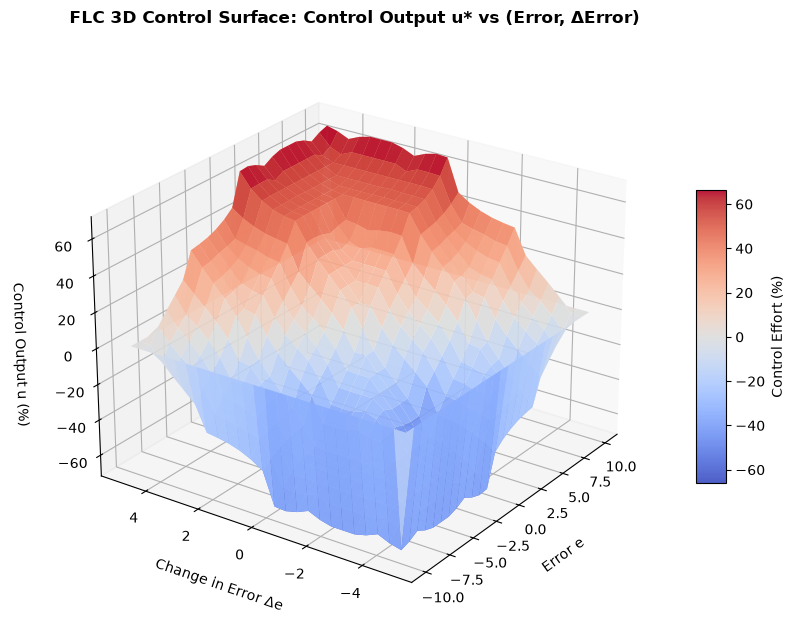


[✓] Control Surface Plot saved to: /Users/manish/Developer/Assignments/Assignment_2_Practicals/Module_1_Fuzzy_Logic/../output_plots/mod1_ex10_flc_controller.png
[✓] Practical 1.10 completed successfully.



In [11]:
import os
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

OUTPUT_DIR = os.path.join(os.getcwd(), "..", "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x - a)/(b - a + 1e-12), (c - x)/(c - b + 1e-12)), 0.0)

# Universes: e in [-10, 10], de in [-5, 5], u in [-100, 100]
u_e = np.linspace(-10, 10, 300)
u_de = np.linspace(-5, 5, 300)
u_ctrl = np.linspace(-100, 100, 500)

# Partition definition dictionary
def get_partitions(u, span):
    w = span / 2.0
    return {
        'NB': trimf(u, -span, -span, -w),
        'NS': trimf(u, -span, -w, 0),
        'ZE': trimf(u, -w, 0, w),
        'PS': trimf(u, 0, w, span),
        'PB': trimf(u, w, span, span)
    }

mf_e = get_partitions(u_e, 10.0)
mf_de = get_partitions(u_de, 5.0)
mf_u = get_partitions(u_ctrl, 100.0)

# 25-Rule MacVicar-Whelan Rule Matrix
# Rows: Error (NB, NS, ZE, PS, PB)
# Cols: Change in Error (NB, NS, ZE, PS, PB)
RULE_MATRIX = {
    ('NB', 'NB'): 'NB', ('NB', 'NS'): 'NB', ('NB', 'ZE'): 'NB', ('NB', 'PS'): 'NS', ('NB', 'PB'): 'ZE',
    ('NS', 'NB'): 'NB', ('NS', 'NS'): 'NS', ('NS', 'ZE'): 'NS', ('NS', 'PS'): 'ZE', ('NS', 'PB'): 'PS',
    ('ZE', 'NB'): 'NB', ('ZE', 'NS'): 'NS', ('ZE', 'ZE'): 'ZE', ('ZE', 'PS'): 'PS', ('ZE', 'PB'): 'PB',
    ('PS', 'NB'): 'NS', ('PS', 'NS'): 'ZE', ('PS', 'ZE'): 'PS', ('PS', 'PS'): 'PS', ('PS', 'PB'): 'PB',
    ('PB', 'NB'): 'ZE', ('PB', 'NS'): 'PS', ('PB', 'ZE'): 'PB', ('PB', 'PS'): 'PB', ('PB', 'PB'): 'PB',
}

def flc_step(e_val, de_val):
    """Evaluates the FLC for crisp (e, de) and returns crisp control action u*."""
    # Fuzzify
    mu_e = {k: float(np.interp(e_val, u_e, v)) for k, v in mf_e.items()}
    mu_de = {k: float(np.interp(de_val, u_de, v)) for k, v in mf_de.items()}

    aggregated = np.zeros_like(u_ctrl)

    for (term_e, term_de), term_u in RULE_MATRIX.items():
        w = min(mu_e[term_e], mu_de[term_de])
        if w > 0:
            clipped = np.minimum(w, mf_u[term_u])
            aggregated = np.maximum(aggregated, clipped)

    denom = np.sum(aggregated)
    if denom == 0:
        return 0.0
    return float(np.sum(u_ctrl * aggregated) / denom)

def run_practical_10():
    print("=" * 60)
    print("PRACTICAL 1.10: Complete Fuzzy Logic Controller (FLC)")
    print("=" * 60)

    # 1. Test specific points
    test_cases = [(4.5, -1.2), (-8.0, 0.5), (0.1, 0.0), (8.5, 3.2)]
    print("\nEvaluating FLC Output for Test States (Error, Change_in_Error):")
    print("-" * 55)
    for e_in, de_in in test_cases:
        u_out = flc_step(e_in, de_in)
        print(f"Error = {e_in:5.1f} | ΔError = {de_in:5.1f} -> Control Action u* = {u_out:6.2f}%")

    # 2. Compute 3D Control Surface
    e_grid = np.linspace(-10, 10, 25)
    de_grid = np.linspace(-5, 5, 25)
    E, DE = np.meshgrid(e_grid, de_grid)
    U = np.zeros_like(E)

    for i in range(E.shape[0]):
        for j in range(E.shape[1]):
            U[i, j] = flc_step(E[i, j], DE[i, j])

    fig = plt.figure(figsize=(10, 6.5))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(E, DE, U, cmap='coolwarm', edgecolor='none', alpha=0.9)
    ax.set_title("FLC 3D Control Surface: Control Output u* vs (Error, ΔError)", fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel("Error e", labelpad=10)
    ax.set_ylabel("Change in Error Δe", labelpad=10)
    ax.set_zlabel("Control Output u (%)", labelpad=10)
    fig.colorbar(surf, shrink=0.5, aspect=10, label='Control Effort (%)')
    ax.view_init(elev=25, azim=215)
    plt.tight_layout()

    plot_path = os.path.join(OUTPUT_DIR, "mod1_ex10_flc_controller.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    print(f"\n[✓] Control Surface Plot saved to: {plot_path}")
    print("[✓] Practical 1.10 completed successfully.\n")

if True:
    run_practical_10()